# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.1 Базовая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с базовыми подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за эту часть — 6 баллов. Детальнее про оценивание — в самом конце ноутбука.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-base-Username.ipynb**, где Username — ваша фамилия.

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом домашнем задании мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Целевая метрика уже выбрана за нас: мы будем считать $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией. При желании это можно доделать до целого пет-проекта, особенно если добавить сбор данных и деплой модели, но в дз этого не будет :(.

Цель конкретно базового ноутбука — познакомить вас с основными преобразованиями и собрать солидный фундамент для преобразований посложнее.

In [ ]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У вас на руках (на Kaggle) датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Если вы не знакомы с игрой — ничего страшного, все необходимое для заданий в базовой части мы подробно опишем.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов (например, чтобы делать ставки на спорт, осуждаем?). Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

#### 📌 **Важнейшее замечание**

Предполагается, что у вас уже сложилось понимание:
- как крутить и вертеть данные, чтобы фиты делались твёрдо, трансформы ложились чётко, шейпы датафреймов стакались и нужные джойны джойнились;
- как рисовать читаемые графики;
- как проверять качество модели;

Пожалуйста, следите за этим очень-очень внимательно, иначе рискуете получить штраф и всеобщее порицание в нашем уютном МО-1 чатике (хотя, у этого есть плюсы).

Если возникнут вопросы по игровой части — **не стесняйтесь** спрашивать, гуглить, обращаться к GPT или, прости Господи, дотерам. Знание области — важнейшая составляющая хорошего фича инжиниринга

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Для лучшего понимания, в голубеньких пунктах будет небольшое <font color="#7298ce">**обоснование**</font> того, зачем вообще делается то или иное преобразование (в колабе придётся включать интуицию, там не работает HTML). Вы можете её скипнуть, если всё понятно и без этого

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

В пунктах с розоватой, как у всеми любимого Pudge, расцветкой мы попросим вас написать <font color="#f68c9d">**Ответ**</font> на <font color="#f68c9d">**Вопрос**</font> или <font color="#f68c9d">**рефлексию**</font>, которая должна направить вашу мысль о том, как варить фичи, в нужном направлении. Уметь аргументировать свою точку зрения важно не менее

Пожалуйста, даже если вы уже прожжённый дед инсайд и дата-сайентист 14 уо, всё равно <font color="#f68c9d">**порефлексируйте**</font>. Количество потерянных нервных клеток и ваш успех на соревновании напрямую зависят от базовой предобработки.
Вы **можете** писать <font color="#f68c9d">**её**</font> ёмко, но только если **знаете** ответ

</div>

<div style="border-left: 5px solid #d18753; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(200, 156, 105, 0.05);">

<font>По ходу домашки вам придётся делать <font color="#d18753">**выборы**</font> и подбирать <font color="#d18753">**гиперпараметры**</font>. Какие-то из них важнее остальных. У ряда выборов последствия чисто номинальные, какие-то видоизменят другие задания, третьи полностью определят, как вы будете делать остальную домашку.

Принимайте решения мудро. Не привязывайтесь к ним слишком сильно, возможно, в процессе вам захочется пересмотреть ваши жизненные приоритеты. Пробуйте, экспериментируйте, фичи это самое творческое, что есть в машинном обучении

При желании, в конце обоих ноутбуков есть инструменты, которые, при остром желании и избытке свободного времени, могут тупо перебрать все выборы и найти самый оптимальный, но это опционально
</div>

### **Часть 1. Это, так сказать, база. (3.25 балла)** <img align="center" height=28 width=28 src="https://media.tenor.com/5vGX5VO-IxsAAAAi/arthas.gif">

В которой студент учится смотреть на фичи под правильным углом и готовить из сырых данных простые, но аппетитные факторы

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

сначала сделаем все возможные и невозможные импорты

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:

train_path = Path("matches_df_train.csv")
test_path  = Path("matches_df_test.csv")
matches_df_train = pd.read_csv(train_path)
matches_df_test  = pd.read_csv(test_path)
size_train_mb = train_path.stat().st_size / (1024 ** 2)
print("matches_df_train.csv")
print(f"Размер файла: {size_train_mb:.2f} МБ")
print(f"Shape: {matches_df_train.shape}")
print("Типы колонок:")
print(matches_df_train.dtypes)
size_test_mb = test_path.stat().st_size / (1024 ** 2)
print("matches_df_test.csv")
print(f"Размер файла: {size_test_mb:.2f} МБ")
print(f"Shape: {matches_df_test.shape}")
print("Типы колонок:")
print(matches_df_test.dtypes)


matches_df_train.csv
Размер файла: 4.00 МБ
Shape: (90217, 7)
Типы колонок:
match_id         int64
date            object
region          object
game_mode        int64
duration         int64
radiant_win       bool
avg_mmr        float64
dtype: object
matches_df_test.csv
Размер файла: 2.08 МБ
Shape: (59748, 5)
Типы колонок:
match_id       int64
date          object
region        object
game_mode      int64
avg_mmr      float64
dtype: object


Отдельно хочется посмотреть распределение целевой переменной, покажите его, пожалуйста

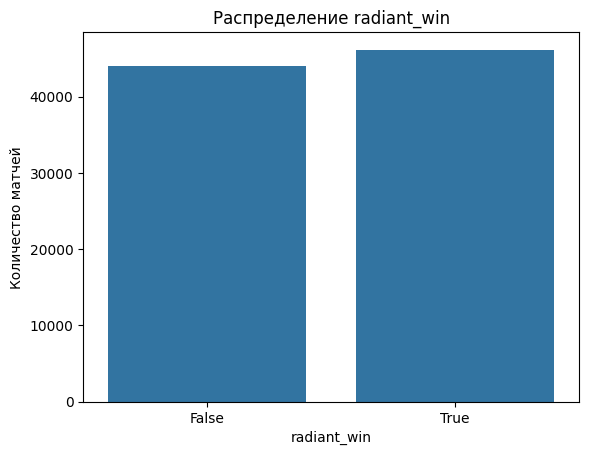

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
sns.countplot(x=matches_df_train["radiant_win"])
plt.title("Распределение radiant_win")
plt.xlabel("radiant_win")
plt.ylabel("Количество матчей")
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:** да, подходящая, тк у нас почти одинаковый шанс проигрыша и выигрыша. а AUC-PR обычно используется, когда у нас большой отрицальный класс и редкий положительный.
</div>

#### **Задание 1.2. Категории** (0.75 балла)

Чтобы построить реально балдёжную модель, зачастую не получится просто написать фит предикт. О нет, это долгая и утомительная возня. А если нужно ещё и отчётики писать, то хоть <span style="color:grey"><font size="1">~~вешайся (осуждаем)~~ </font></span> увольняйся. Так и здесь. И того, что есть, уже хватит, чтобы продемонстрировать глубокую и тёмную сторону Dota Science.

В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше

</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

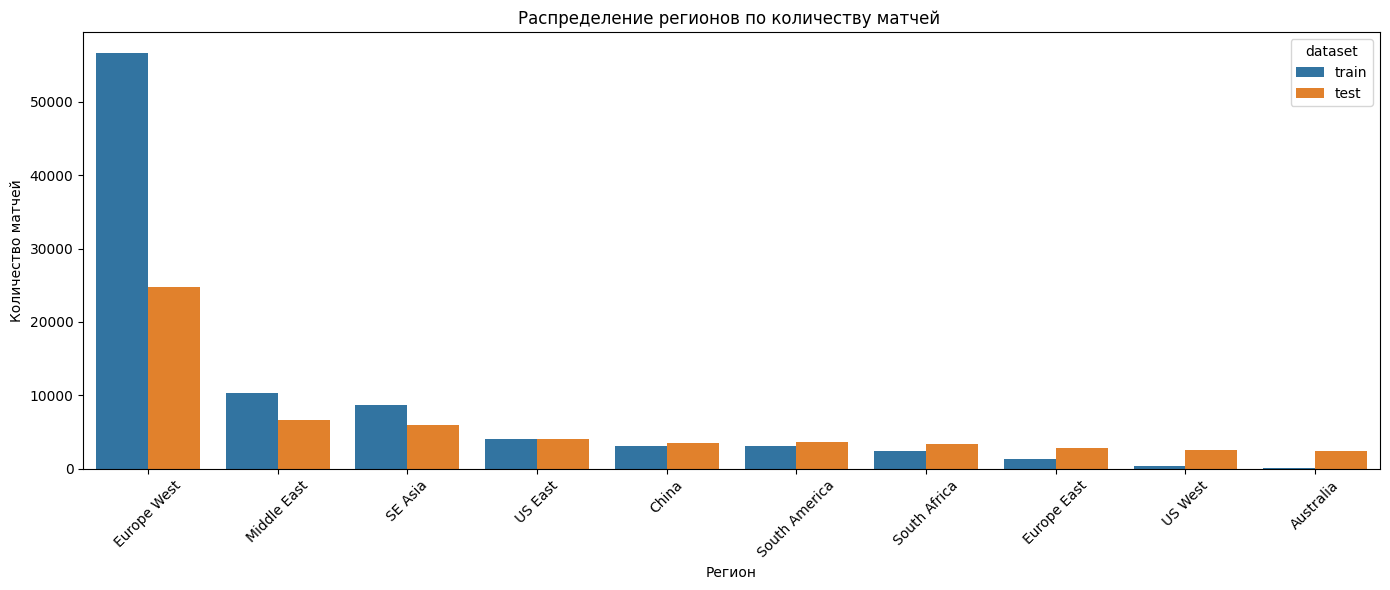

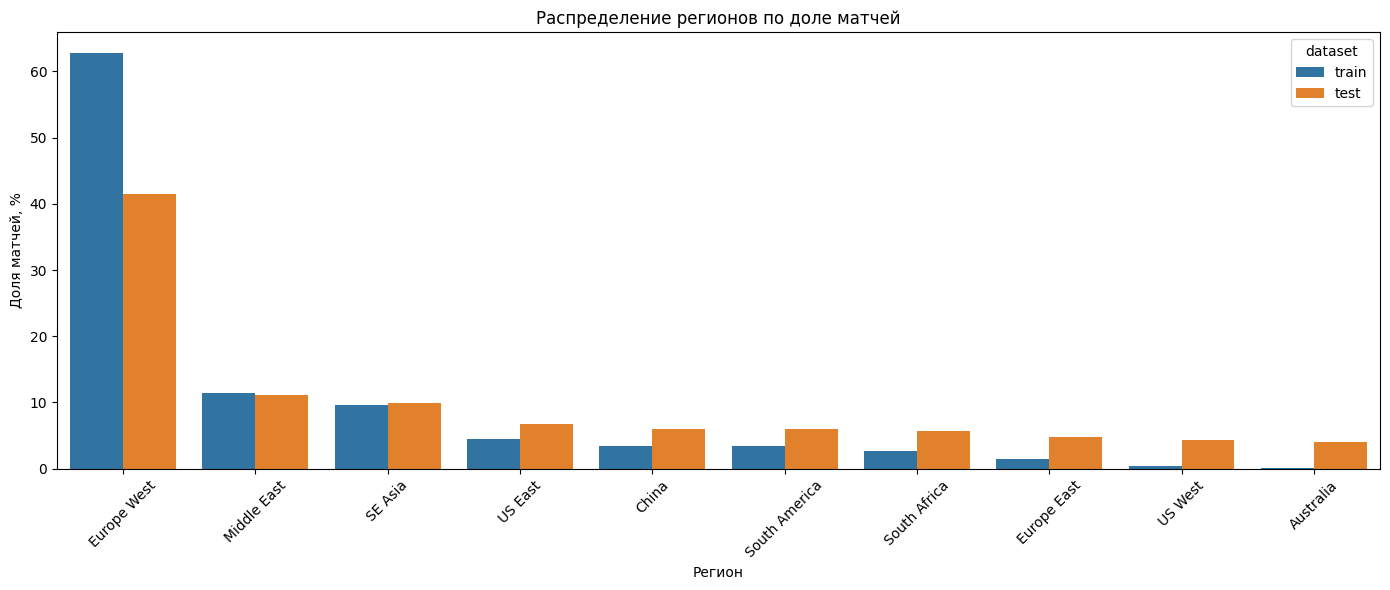

In [ ]:
region_col = "region"
target_col = "radiant_win"
train_counts = (
    matches_df_train[region_col]
    .value_counts()
    .rename("count")
    .reset_index()
    .rename(columns={"index": "region"})
)
train_counts["dataset"] = "train"
test_counts = (
    matches_df_test[region_col]
    .value_counts()
    .rename("count")
    .reset_index()
    .rename(columns={"index": "region"})
)
test_counts["dataset"] = "test"
dist_df = pd.concat([train_counts, test_counts], ignore_index=True)
dist_df["pct"] = dist_df.groupby("dataset")["count"].transform(
    lambda x: x / x.sum() * 100
)
plt.figure(figsize=(14, 6))
sns.barplot(
    data=dist_df,
    x="region",
    y="count",
    hue="dataset",
)
plt.title("Распределение регионов по количеству матчей ")
plt.xlabel("Регион")
plt.ylabel("Количество матчей")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=dist_df,
    x="region",
    y="pct",
    hue="dataset",
)
plt.title("Распределение регионов по доле матчей")
plt.xlabel("Регион")
plt.ylabel("Доля матчей, %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:**   больше всего матчей сыграно в регионе Europe West, дальше идут  Middle East и SE Asia. Из‑за такого перекоса модель в первую очередь будет учиться на матчах из Europe West, а по редким регионам её поведение будет менее чётким. Тем не менее,  доли и средняя radiant_win по регионам отличаются, некий сигнал в признаке «регион» есть, и его имеет смысл использовать, просто аккуратно относиться к выводам по тем регионам, где данных совсем мало, но модель обучится
</div>

Наша первая развилка — <font color="#d18753">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#d18753">**One-Hot Encoder**</font> | <font color="#d18753">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">
Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора
</div>

In [ ]:
!pip install -qU category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.5 MB/s eta 0:00:00


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:** мне больше нравится one‑hot encoding, потому что он простой, не использует информацию о таргете и хорошо подходит при умеренном числе категорий
</div>

Закодируйте колонку `region` выбранным вами способом

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
region_col = "region"
train_regions = matches_df_train[region_col]
test_regions = matches_df_test[region_col]
regions_all = pd.concat([train_regions, test_regions])
regions_all_ohe = pd.get_dummies(regions_all, prefix="region")
region_ohe_train = regions_all_ohe.iloc[:len(matches_df_train)]
region_ohe_test = regions_all_ohe.iloc[len(matches_df_train):]
matches_df_train_ohe = pd.concat(
    [matches_df_train.drop(columns=[region_col]), region_ohe_train],
    axis=1
)
matches_df_test_ohe = pd.concat(
    [matches_df_test.drop(columns=[region_col]), region_ohe_test],
    axis=1
)
matches_df_train_ohe.head()

,match_id,date,game_mode,duration,radiant_win,avg_mmr,region_Australia,region_China,region_Europe East,region_Europe West,region_Middle East,region_SE Asia,region_South Africa,region_South America,region_US East,region_US West
0,1,2024-02-12,4,2625,False,3519.7,False,False,False,True,False,False,False,False,False,False
1,2,2024-04-08,2,7526,True,2330.9,False,False,False,False,False,False,True,False,False,False
2,3,2024-06-16,1,2831,True,1579.6,False,False,False,False,False,True,False,False,False,False
3,4,2024-09-16,22,1438,False,NaN,False,False,False,False,True,False,False,False,False,False
4,5,2024-03-31,22,2051,True,NaN,False,False,False,False,False,False,True,False,False,False


#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

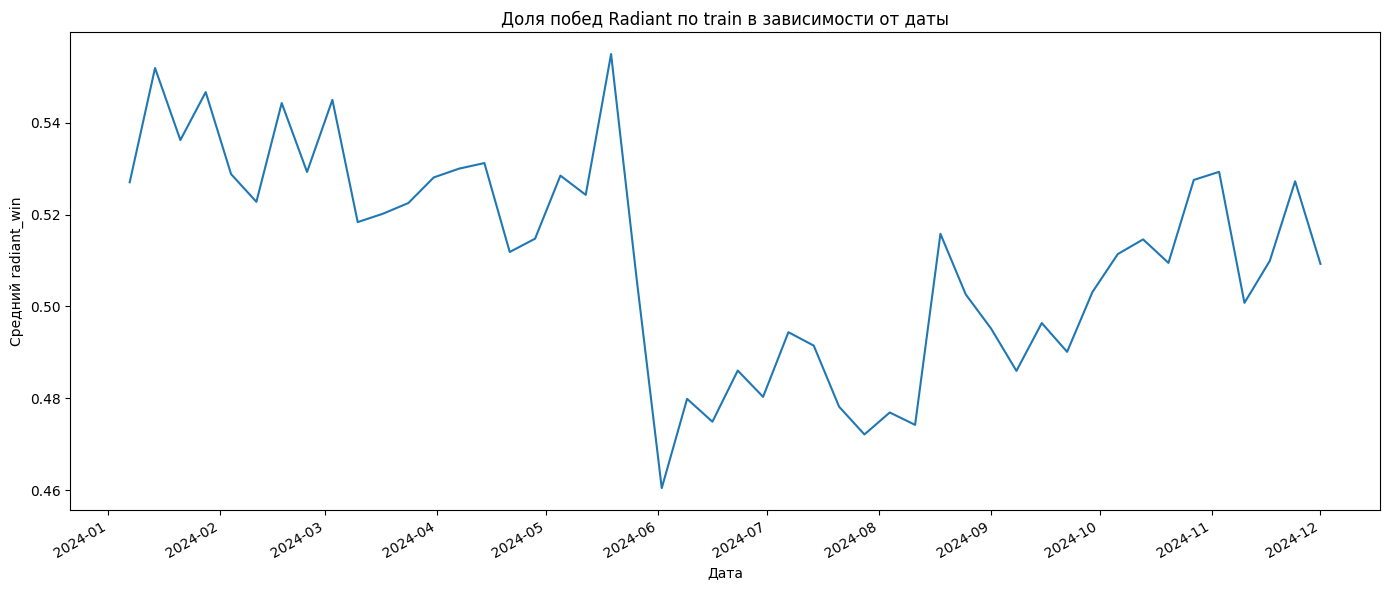

Train диапазон: 2024-01-01 00:00:00 → 2024-11-30 00:00:00
Test  диапазон: 2024-12-01 00:00:00 → 2024-12-31 00:00:00


In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
date_col = "date"
target_col = "radiant_win"
matches_df_train_ohe[date_col] = pd.to_datetime(matches_df_train_ohe[date_col])
matches_df_test_ohe[date_col]  = pd.to_datetime(matches_df_test_ohe[date_col])
winrate_by_week = (matches_df_train_ohe.set_index(date_col).resample("W")[target_col].mean().reset_index().rename(columns={target_col: "radiant_win_mean"}))
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=winrate_by_week,
    x=date_col,
    y="radiant_win_mean"
)
plt.title("Доля побед Radiant по train в зависимости от даты")
plt.xlabel("Дата")
plt.ylabel("Средний radiant_win")
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()
train_min, train_max = (
    matches_df_train_ohe[date_col].min(),
    matches_df_train_ohe[date_col].max()
)
test_min, test_max = (
    matches_df_test_ohe[date_col].min(),
    matches_df_test_ohe[date_col].max()
)
print("Train диапазон:", train_min, "→", train_max)
print("Test  диапазон:", test_min,  "→", test_max)

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:** диапазон дат показывает, что обучающая выборка покрывает матчи с января по конец ноября 2024 года, а тестовая только декабрь. в доте в это время регулярно выходят патчи(обновления), которые заметно меняют баланс и игровые стратегии. Поэтому декабрьские матчи могут статистически отличаться от матчей предыдущих месяцев, и это разделение позволяет проверить, насколько модель устойчива к изменениям меты и правил игры

</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.html) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#d18753">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#d18753">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:** добавим признаки month и is_weekend. проверим в какой месяц светлая сторона выигрывает чаще и влияют ли выходные на этот показатель, тк разные аудитории людей могут играть в разное время, что чисто в теории может повлиять на таргетную переменную

</div>

3. Закодируйте новые признаки, согласно вашему ответу

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
date_col = "date"
matches_df_train_ohe[date_col] = pd.to_datetime(matches_df_train_ohe[date_col])
matches_df_test_ohe[date_col]  = pd.to_datetime(matches_df_test_ohe[date_col])
for df in (matches_df_train_ohe, matches_df_test_ohe):
    df["day"] = df[date_col].dt.day
    df["weekday"] = df[date_col].dt.weekday
    df["month"] = df[date_col].dt.month
    df["is_weekend"] = (df["weekday"] >= 5).astype(int)

Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:** потому что рандомное разделение перемешает будущие и прошлые данные, часть матчей, которые были в начале, окажутся в трене, а часть в валидации. В итоге модель на валидации получит почти те же самые условия, что уже были в обучении, и качество получается слишком точноым, тк мы уже заранее знаем ответы, то есть произошла утечка из будущего
</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#d18753">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#d18753">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#d18753">**трешхолд**</font> `t` или <font color="#d18753">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
from sklearn.model_selection import TimeSeriesSplit
n_folds = 4
tscv = TimeSeriesSplit(n_splits=n_folds)
X = matches_df_train_ohe.drop(columns=["radiant_win"])
y = matches_df_train_ohe["radiant_win"]
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    print(f"Fold {fold + 1}")
    print(f"Train size: {len(train_idx)}")
    print(f"Validation size: {len(val_idx)}")

Fold 1
Train size: 18045
Validation size: 18043
Fold 2
Train size: 36088
Validation size: 18043
Fold 3
Train size: 54131
Validation size: 18043
Fold 4
Train size: 72174
Validation size: 18043


И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#d18753">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#d18753">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#d18753"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#d18753"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#d18753"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#d18753"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#d18753"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#d18753"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#d18753">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#d18753">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#d18753">**NB**</font>:

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но небольшой буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
date_features = ["day", "weekday", "month", "is_weekend"]
region_features = [
    "region_Australia",
    "region_China",
    "region_Europe East",
    "region_Europe West",
    "region_Middle East",
    "region_SE Asia",
    "region_South Africa",
    "region_South America",
    "region_US East",
    "region_US West",
]
target_col = "radiant_win"
def cv_score_for_features(feature_cols):
    X = matches_df_train_ohe[feature_cols]
    y = matches_df_train_ohe[target_col]
    tscv = TimeSeriesSplit(n_splits=4)
    scores = []
    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, y_pred)
        scores.append(score)
    return scores
scores_dates = cv_score_for_features(date_features)
scores_regions = cv_score_for_features(region_features)
scores_both = cv_score_for_features(date_features + region_features)
print("Dates only:",  sum(scores_dates)/len(scores_dates))
print("Regions only:",   sum(scores_regions)/len(scores_regions))
print("Dates + regions:",   sum(scores_both)/len(scores_both))

Dates only: 0.5118358150677875
Regions only: 0.5357497052431244
Dates + regions: 0.5411601536417727


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:** даты совсем чуть-чуть помогают в вычислениях, тк сами по себе являются довольно слабыми признаками и проигрывают в конкуренции другим (например, персонажам, картам и тд), они не должны помогать, но их можно оставить, тк они просты и не затратны в вычислениях, а даже небольшой плюс это тоже плюс

</div>

#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

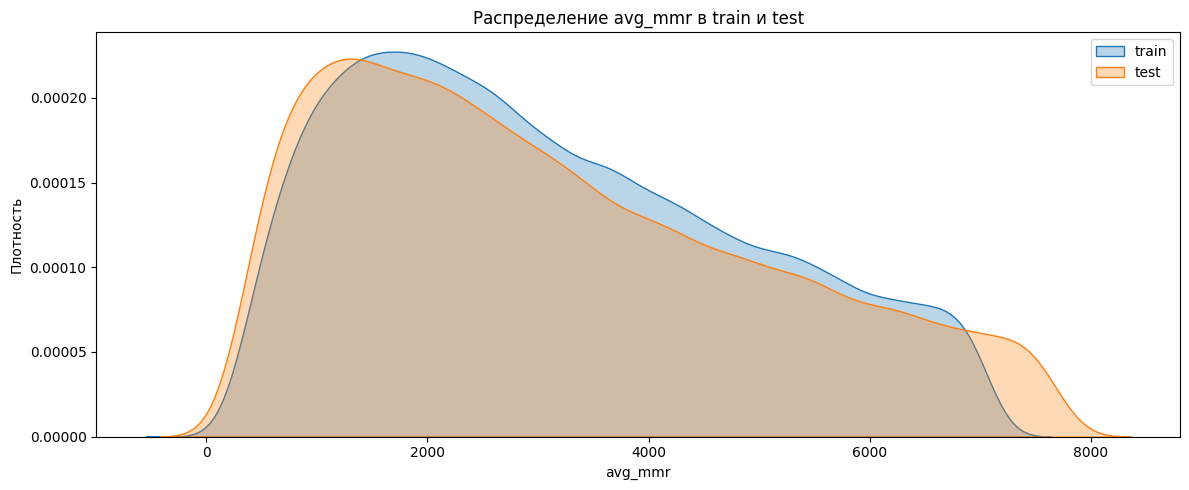

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
plt.figure(figsize=(12, 5))
sns.kdeplot(data=matches_df_train_ohe, x="avg_mmr", label="train", fill=True, alpha=0.3)
sns.kdeplot(data=matches_df_test_ohe, x="avg_mmr", label="test", fill=True, alpha=0.3)
plt.title("Распределение avg_mmr в train и test")
plt.xlabel("avg_mmr")
plt.ylabel("Плотность")
plt.legend()
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам?

**Ответ:** похоже на график логнормального распределения

</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но на практике это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте

Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

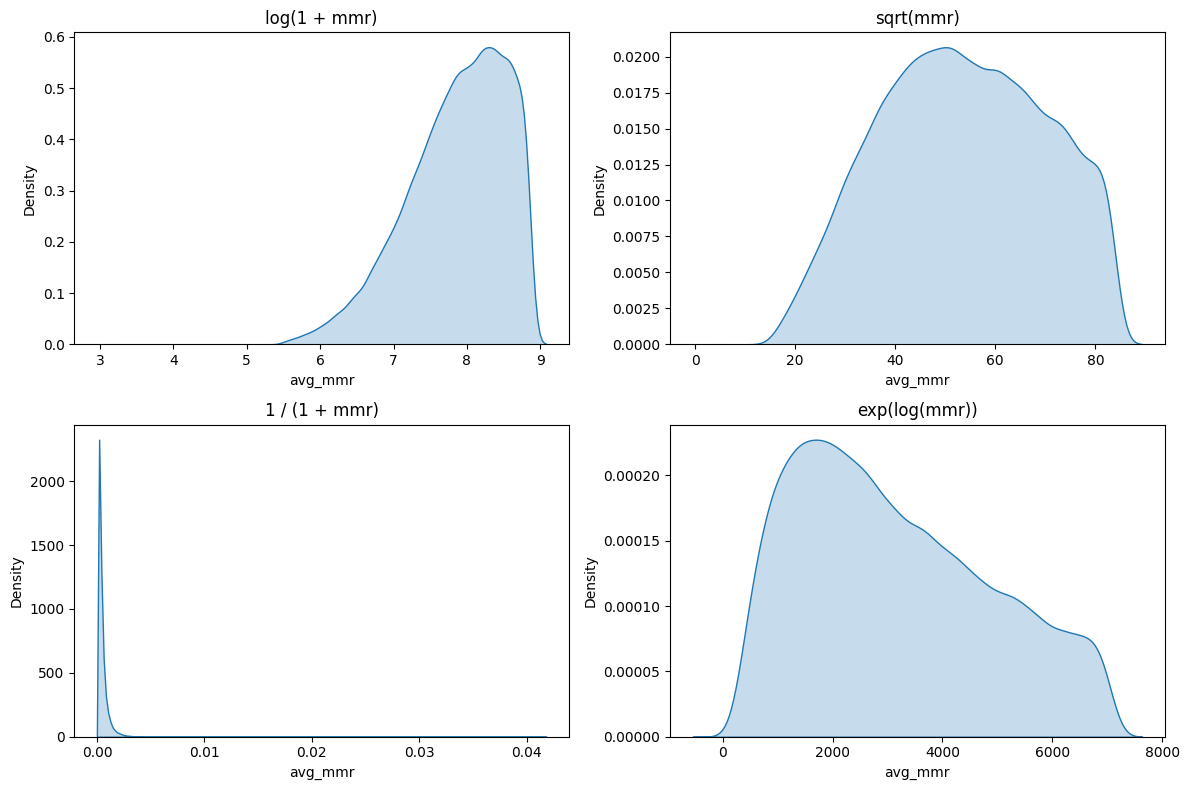

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
mmr = matches_df_train["avg_mmr"]
transforms = { "log(1 + mmr)": np.log1p(mmr),  "sqrt(mmr)": np.sqrt(mmr),  "1 / (1 + mmr)": 1 / (1 + mmr), "exp(log(mmr))": np.exp(np.log(mmr.replace(0, np.nan))) }
plt.figure(figsize=(12,8))
for i, (name, values) in enumerate(transforms.items(), 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(values.dropna(), fill=True)
    plt.title(name)
plt.tight_layout()
plt.show()

Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#d18753">**Можете**</font> замерить его влияние, если есть желание, может это полная дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:** нет, нулями нельзя заполнять в этом случае, тк это не нормальное значение и он сильно подкосит модель. лучше заполнять их средним значением

</div>

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на тесте

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на тесте \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

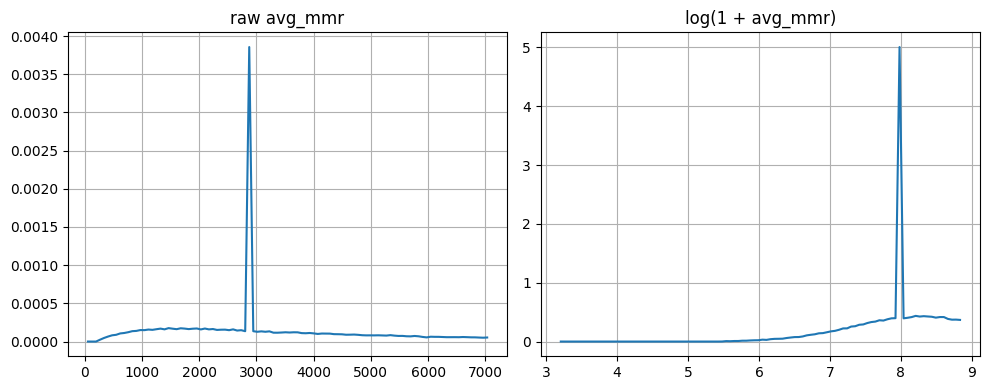

BASE MODEL: AUC=0.5412  Gini=0.0823
RAW  MMR:   AUC=0.5735  Gini=0.1471
LOG1P MMR:  AUC=0.5745  Gini=0.1489


In [ ]:
df = matches_df_train_ohe.copy()
date_col = "date"
df[date_col] = pd.to_datetime(df[date_col])
df["day"] = df[date_col].dt.day
df["weekday"] = df[date_col].dt.weekday
df["month"] = df[date_col].dt.month
df["is_weekend"] = (df["weekday"] >= 5).astype(int)
df["mmr_missing"] = df["avg_mmr"].isna().astype(int)
mmr_median = df["avg_mmr"].median()
df["avg_mmr"] = df["avg_mmr"].fillna(mmr_median)
df["avg_mmr_log"] = np.log1p(df["avg_mmr"])
def line_from_hist(x, bins=100):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    counts, edges = np.histogram(x, bins=bins, density=True)
    centers = 0.5 * (edges[1:] + edges[:-1])
    return centers, counts
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
xs, ys = line_from_hist(df["avg_mmr"])
plt.plot(xs, ys)
plt.title("raw avg_mmr")
plt.grid(True)
plt.subplot(1,2,2)
xs, ys = line_from_hist(df["avg_mmr_log"])
plt.plot(xs, ys)
plt.title("log(1 + avg_mmr)")
plt.grid(True)
plt.tight_layout()
plt.show()
date_features = ["day","weekday","month","is_weekend"]
region_features = [c for c in df.columns if c.startswith("region_")]
base_features = date_features + region_features
target_col = "radiant_win"
def cv_score_for_features(feature_cols):
    X = df[feature_cols]
    y = df[target_col]
    tscv = TimeSeriesSplit(n_splits=4)
    auc_scores = []
    for train_idx, val_idx in tscv.split(X):
        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]
        model = LogisticRegression(max_iter=5000)
        model.fit(X_train, y_train)
        pred = model.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val, pred)
        auc_scores.append(auc)
    auc_mean = np.mean(auc_scores)
    gini = 2*auc_mean - 1
    return auc_mean, gini
auc_base, gini_base = cv_score_for_features(base_features)
features_raw = base_features + ["avg_mmr","mmr_missing"]
auc_raw, gini_raw = cv_score_for_features(features_raw)
features_log = base_features + ["avg_mmr_log","mmr_missing"]
auc_log, gini_log = cv_score_for_features(features_log)
print(f"BASE MODEL: AUC={auc_base:.4f}  Gini={gini_base:.4f}")
print(f"RAW  MMR:   AUC={auc_raw:.4f}  Gini={gini_raw:.4f}")
print(f"LOG1P MMR:  AUC={auc_log:.4f}  Gini={gini_log:.4f}")

### **Часть 2. Векторы** (1.5 балла) <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

В которой студент испытывает вьетнамские флешбеки от дз1, фиксит чужие баги и делает нереально мощную фичу, которую можно полировать до посинения

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
player_df = pd.read_csv("player_df.csv")
print("Кол-во строк:", len(player_df))
print("Кол-во уникальных account_id:", player_df["account_id"].nunique(dropna=False))
print()
print("Топ-20 самых частых account_id:")
print(player_df["account_id"].value_counts(dropna=False).head(20))
print()
suspicious_ids = [0, 4294967295]
print("Подозрительные account_id:")
for acc_id in suspicious_ids:
    cnt = (player_df["account_id"] == acc_id).sum()
    print(f"account_id = {acc_id}: {cnt} строк")
print()
print("Минимальные account_id:")
print(sorted(player_df["account_id"].dropna().unique())[:10])
print()
print("Максимальные account_id:")
print(sorted(player_df["account_id"].dropna().unique())[-10:])
print()
bad_accounts_df = player_df[player_df["account_id"].isin(suspicious_ids)].copy()
print("Примеры строк с подозрительными account_id:")
display(bad_accounts_df.head(10))
player_df["account_id_special"] = player_df["account_id"].isin(suspicious_ids).astype(int)
print()
print("Распределение флага account_id_special:")
print(player_df["account_id_special"].value_counts(dropna=False))

Кол-во строк: 5786409
Кол-во уникальных account_id: 867877

Топ-20 самых частых account_id:
account_id
 4294967295    2114803
-1               20650
 37619671          597
 137331734         583
 87266522          582
 62933415          571
 38584608          567
 84244723          566
 151993649         564
 85427446          558
 64800968          539
 198434112         527
 49092801          520
 186054714         519
 13934403          512
 10856368          505
 58941133          503
 86770710          502
 89843621          497
 2727508           496
Name: count, dtype: int64

Подозрительные account_id:
account_id = 0: 0 строк
account_id = 4294967295: 2114803 строк

Минимальные account_id:
[np.int64(-1), np.int64(111), np.int64(343), np.int64(695), np.int64(1227), np.int64(1284), np.int64(1433), np.int64(1603), np.int64(1952), np.int64(1985)]

Максимальные account_id:
[np.int64(279000168), np.int64(279004808), np.int64(279020652), np.int64(279026254), np.int64(279066464), np.int6

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576.0
10,128,4294967295,71,36.0,15.0,15.0,2742.0,76.0,4.0,538.0,645.0,34688.0,1177.0,251954.0
18,2,4294967295,65,2.0,10.0,9.0,277.0,98.0,1.0,326.0,386.0,6117.0,272.0,738147.0
20,128,4294967295,7,14.0,13.0,17.0,1846.0,251.0,0.0,361.0,474.0,22276.0,183.0,474296.0
25,128,4294967295,15,4.0,9.0,4.0,311.0,79.0,3.0,302.0,350.0,10442.0,88.0,242554.0
28,128,4294967295,45,9.0,6.0,17.0,1994.0,117.0,1.0,538.0,558.0,14513.0,957.0,716430.0
29,128,4294967295,30,4.0,4.0,20.0,3761.0,70.0,1.0,344.0,404.0,6350.0,688.0,227299.0
33,128,4294967295,54,7.0,8.0,14.0,5141.0,187.0,3.0,573.0,736.0,10594.0,2800.0,206177.0
38,128,4294967295,105,10.0,10.0,9.0,1361.0,38.0,0.0,325.0,336.0,14674.0,1538.0,145340.0
39,4,4294967295,75,5.0,12.0,16.0,426.0,10.0,6.0,268.0,303.0,9391.0,568.0,413435.0



Распределение флага account_id_special:
account_id_special
0    3671606
1    2114803
Name: count, dtype: int64


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:** не можем, тк таких записей немало, и это приведёт к существенной потере данных.Тем более проблема относится не к матчу целиком, а к отдельным игрокам внутри матча, те нельзя идентифицировать конкретного игрока, но остальные данные по матчу при этом остаются полезными

</div>

Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
dup_hero_rows = player_df[player_df.duplicated(subset=["match_id", "hero_id"], keep=False)].copy()
print("Количество строк с повторяющимися героями внутри матча:", len(dup_hero_rows))
print("Количество матчей, где есть повторяющиеся hero_id:", dup_hero_rows["match_id"].nunique())
bad_match_ids = dup_hero_rows["match_id"].unique()
print("Количество плохих match_id:", len(bad_match_ids))
total_matches = player_df["match_id"].nunique()
bad_matches_cnt = len(bad_match_ids)
print("Всего матчей:", total_matches)
print("Плохих матчей:", bad_matches_cnt)
print("Доля плохих матчей: {:.4%}".format(bad_matches_cnt / total_matches))
player_df_clean = player_df[~player_df["match_id"].isin(bad_match_ids)].copy()
print("Размер player_df до очистки:", player_df.shape)
print("Размер player_df после очистки:", player_df_clean.shape)

Количество строк с повторяющимися героями внутри матча: 2961
Количество матчей, где есть повторяющиеся hero_id: 834
Количество плохих match_id: 834
Всего матчей: 767601
Плохих матчей: 834
Доля плохих матчей: 0.1087%
Размер player_df до очистки: (5786409, 15)
Размер player_df после очистки: (5781875, 15)


Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

In [ ]:
player_df = pd.read_csv("player_df.csv")
matches_train = pd.read_csv("matches_df_train.csv")
matches_test  = pd.read_csv("matches_df_test.csv")
print("Исходный размер player_df:", player_df.shape)
dup_hero_rows = player_df[player_df.duplicated(
    subset=["match_id", "hero_id"], keep=False
)].copy()
print("Количество матчей с повторяющимися hero_id:", dup_hero_rows["match_id"].nunique())
bad_match_ids_dup_hero = dup_hero_rows["match_id"].unique()
player_df = player_df[~player_df["match_id"].isin(bad_match_ids_dup_hero)].copy()
print("Размер после удаления матчей с повторяющимися героями:", player_df.shape)
bad_hero0_match_ids = player_df.loc[player_df["hero_id"] == 0, "match_id"].unique()
print("Матчей с hero_id = 0:", len(bad_hero0_match_ids))
player_df = player_df[~player_df["match_id"].isin(bad_hero0_match_ids)].copy()
print("Размер после удаления матчей с hero_id=0:", player_df.shape)
special_account_ids = {-1, 4294967295}
player_df["team_side"] = np.where(
    player_df["player_slot"].between(0, 4), "radiant",
    np.where(player_df["player_slot"].between(128, 132), "dire", "other")
)
tmp = player_df[
    player_df["team_side"].isin(["radiant", "dire"]) &
    (~player_df["account_id"].isin(special_account_ids))
].copy()
bad_account_match = (
    tmp.groupby(["match_id", "account_id"])["team_side"]
       .nunique()
       .reset_index()
)
bad_account_match = bad_account_match[bad_account_match["team_side"] > 1]
bad_two_sides_match_ids = bad_account_match["match_id"].unique()
print("Матчей, где игрок был сразу в двух командах:", len(bad_two_sides_match_ids))
player_df = player_df[~player_df["match_id"].isin(bad_two_sides_match_ids)].copy()
print("Размер после удаления матчей с игроками в двух командах:", player_df.shape)
all_match_ids = set(matches_train["match_id"]).union(set(matches_test["match_id"]))
player_df = player_df[player_df["match_id"].isin(all_match_ids)].copy()
print("Размер после фильтрации по матчам train/test:", player_df.shape)
player_df["is_radiant"] = player_df["player_slot"].between(0, 4)
player_df["is_dire"]    = player_df["player_slot"].between(128, 132)
match_team_counts = (
    player_df.groupby("match_id")
    .agg(
        radiant_cnt=("is_radiant", "sum"),
        dire_cnt=("is_dire", "sum"),
        total_players=("match_id", "size")
    )
    .reset_index()
)
bad_team_count_matches = match_team_counts[
    (match_team_counts["radiant_cnt"] != 5) |
    (match_team_counts["dire_cnt"] != 5)
]
bad_team_count_match_ids = bad_team_count_matches["match_id"].unique()
print("Матчей, где не 5 Radiant или не 5 Dire:", len(bad_team_count_match_ids))

player_df = player_df[~player_df["match_id"].isin(bad_team_count_match_ids)].copy()
print("Размер после удаления матчей с некорректным составом:", player_df.shape)
players_per_match = player_df.groupby("match_id").size()
print("Уникальные числа игроков на матч после очистки:", players_per_match.unique())
valid_match_ids = players_per_match[players_per_match == 10].index
print("Матчей с ровно 10 игроками:", len(valid_match_ids))
matches_train = matches_train[matches_train["match_id"].isin(valid_match_ids)].copy()
matches_test  = matches_test [matches_test ["match_id"].isin(valid_match_ids)].copy()
player_train = player_df[player_df["match_id"].isin(matches_train["match_id"])].copy()
player_test  = player_df[player_df["match_id"].isin(matches_test ["match_id"])].copy()
train_match_ids = np.intersect1d(matches_train["match_id"].unique(),
                                 player_train["match_id"].unique())
test_match_ids  = np.intersect1d(matches_test ["match_id"].unique(),
                                 player_test ["match_id"].unique())
print("player_train матчи:", len(train_match_ids))
print("player_test матчи:", len(test_match_ids))

Исходный размер player_df: (7650825, 14)
Количество матчей с повторяющимися hero_id: 1053
Размер после удаления матчей с повторяющимися героями: (7644422, 14)
Матчей с hero_id = 0: 788
Размер после удаления матчей с hero_id=0: (7636672, 14)
Матчей, где игрок был сразу в двух командах: 0
Размер после удаления матчей с игроками в двух командах: (7636672, 15)
Размер после фильтрации по матчам train/test: (6996750, 15)
Матчей, где не 5 Radiant или не 5 Dire: 0
Размер после удаления матчей с некорректным составом: (6996750, 17)
Уникальные числа игроков на матч после очистки: [10]
Матчей с ровно 10 игроками: 699675
player_train матчи: 640030
player_test матчи: 59645


Если вас всё же одолевает паранойя, то ~~я вас понимаю~~ будьте уверены, что если проблемы в `player_df` и остались, на модель они повлияют минимально. Ну а идеала не бывает нигде

#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#d18753">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`).

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч.

Либо же <font color="#d18753">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [ ]:
from scipy.sparse import csr_array
class HeroesEncoder:
    def __init__(self, hero_ids=None):
        self.hero_ids = hero_ids
        self.hero_to_col_ = None
        self.col_to_hero_ = None
        self.n_features_out_ = None

    def fit(self, X, y=None):
        if self.hero_ids is None:
            hero_ids = np.sort(X["hero_id"].unique())
        else:
            hero_ids = np.array(sorted(self.hero_ids))
        self.hero_to_col_ = {h: i for i, h in enumerate(hero_ids)}
        self.col_to_hero_ = {i: h for h, i in self.hero_to_col_.items()}
        self.n_features_out_ = len(hero_ids)
        return self

    def transform(self, X, y=None, match_ids_order=None):
        if self.hero_to_col_ is None:
            raise ValueError("Call fit() before transform().")

        df = X[["match_id", "hero_id", "is_radiant", "is_dire"]].copy()
        df["value"] = np.where(df["is_radiant"], 1,
                               np.where(df["is_dire"], -1, 0))
        df = df[df["value"] != 0].copy()
        df = df[df["hero_id"].isin(self.hero_to_col_)].copy()
        if match_ids_order is None:
            match_ids = np.sort(df["match_id"].unique())
        else:
            exists = np.intersect1d(match_ids_order, df["match_id"].unique())
            match_ids = exists
        match_to_row = {mid: i for i, mid in enumerate(match_ids)}
        df = df[df["match_id"].isin(match_to_row)].copy()

        rows = df["match_id"].map(match_to_row).to_numpy()
        cols = df["hero_id"].map(self.hero_to_col_).to_numpy()
        data = df["value"].to_numpy(dtype=np.int8)
        X_sparse = csr_array(
            (data, (rows, cols)),
            shape=(len(match_ids), self.n_features_out_)
        )
        return X_sparse, match_ids

    def fit_transform(self, X, y=None, match_ids_order=None):
        self.fit(X, y)
        return self.transform(X, y, match_ids_order=match_ids_order)

    def get_feature_names_out(self):
        return np.array(
            [f"hero_{self.col_to_hero_[i]}" for i in range(self.n_features_out_)]
        )
encoder = HeroesEncoder()
X_train_heroes, train_encoded_match_ids = encoder.fit_transform(
    player_train,
    match_ids_order=train_match_ids
)
X_test_heroes, test_encoded_match_ids = encoder.transform(
    player_test,
    match_ids_order=test_match_ids
)
print("X_train_heroes shape:", X_train_heroes.shape)
print("X_test_heroes shape:", X_test_heroes.shape)
train_nnz = np.asarray((X_train_heroes != 0).sum(axis=1)).ravel()
test_nnz  = np.asarray((X_test_heroes != 0).sum(axis=1)).ravel()
print("Уникальные числа ненулевых героев в train:", np.unique(train_nnz).tolist())
print("Уникальные числа ненулевых героев в test:", np.unique(test_nnz).tolist())
print("matches_train матчи vs encoded:", len(train_match_ids), len(train_encoded_match_ids))
print("matches_test матчи vs encoded:", len(test_match_ids), len(test_encoded_match_ids))
train_heroes_df = pd.DataFrame.sparse.from_spmatrix(
    X_train_heroes,
    index=train_encoded_match_ids,
    columns=encoder.get_feature_names_out()
).reset_index().rename(columns={"index": "match_id"})
test_heroes_df = pd.DataFrame.sparse.from_spmatrix(
    X_test_heroes,
    index=test_encoded_match_ids,
    columns=encoder.get_feature_names_out()
).reset_index().rename(columns={"index": "match_id"})
matches_train_encoded = matches_train.merge(train_heroes_df, on="match_id", how="inner")
matches_test_encoded  = matches_test.merge(test_heroes_df, on="match_id", how="inner")
print("matches_train_encoded shape:", matches_train_encoded.shape)
print("matches_test_encoded shape:", matches_test_encoded.shape)

X_train_heroes shape: (640030, 110)
X_test_heroes shape: (59645, 110)
Уникальные числа ненулевых героев в train: [10]
Уникальные числа ненулевых героев в test: [10]
matches_train матчи vs encoded: 640030 640030
matches_test матчи vs encoded: 59645 59645
matches_train_encoded shape: (640030, 117)
matches_test_encoded shape: (59645, 115)


Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
train_df = matches_train_encoded.copy()
target_col = "radiant_win"
date_col = "date"
train_df[date_col] = pd.to_datetime(train_df[date_col])
train_df["day"] = train_df[date_col].dt.day
train_df["weekday"] = train_df[date_col].dt.weekday
train_df["month"] = train_df[date_col].dt.month
train_df["is_weekend"] = (train_df["weekday"] >= 5).astype(int)
train_df["mmr_missing"] = train_df["avg_mmr"].isna().astype(int)
mmr_median = train_df["avg_mmr"].median()
train_df["avg_mmr"] = train_df["avg_mmr"].fillna(mmr_median)
train_df["avg_mmr_log"] = np.log1p(train_df["avg_mmr"])
hero_cols = [c for c in train_df.columns if c.startswith("hero_")]
drop_cols = ["match_id", target_col]
base_numeric_cols = [
    c for c in train_df.columns
    if c not in drop_cols
    and not c.startswith("hero_")
    and pd.api.types.is_numeric_dtype(train_df[c])
]
print("Базовые числовые фичи:", base_numeric_cols)
print("Героев фич:", len(hero_cols))
y = train_df[target_col].astype(int)
train_sample = train_df.sample(n=200_000, random_state=42)
y_sample = train_sample[target_col].astype(int)
X_heroes_s = train_sample[hero_cols].to_numpy(dtype="float32")
X_tr_h, X_val_h, y_tr_h, y_val_h = train_test_split(
    X_heroes_s, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)
logit_h = LogisticRegression(max_iter=2000, n_jobs=-1)
logit_h.fit(X_tr_h, y_tr_h)
pred_h = logit_h.predict_proba(X_val_h)[:, 1]
gini_h = 2 * roc_auc_score(y_val_h, pred_h) - 1
print("Gini ток на героях:", gini_h)
all_feature_cols = base_numeric_cols + hero_cols
X_all_s = train_sample[all_feature_cols].to_numpy(dtype="float32")
X_tr_a, X_val_a, y_tr_a, y_val_a = train_test_split(
    X_all_s, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)
logit_a = LogisticRegression(max_iter=2000, n_jobs=-1)
logit_a.fit(X_tr_a, y_tr_a)
pred_a = logit_a.predict_proba(X_val_a)[:, 1]
gini_a = 2 * roc_auc_score(y_val_a, pred_a) - 1
print("Gini на всех фичах:", gini_a)

Базовые числовые фичи: ['game_mode', 'duration', 'avg_mmr', 'day', 'weekday', 'month', 'is_weekend', 'mmr_missing', 'avg_mmr_log']
Героев фич: 110
Gini ток на героях: 0.2647547565955972
Gini на всех фичах: 0.29129979413131113


Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняет данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

### **Часть 3. Оптимизация для уже смешариков (1.25 балла)** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#d18753">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать их со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. \
<font color="#d18753">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#d18753"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \
Выбор, как всегда, в ваших руках.

</div>

In [ ]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 5.1 MB/s eta 0:00:00


In [ ]:
import optuna
train_df = matches_train_encoded.copy()
target_col = "radiant_win"
date_col = "date"
train_df[date_col] = pd.to_datetime(train_df[date_col])
train_df["day"] = train_df[date_col].dt.day
train_df["weekday"] = train_df[date_col].dt.weekday
train_df["month"] = train_df[date_col].dt.month
train_df["is_weekend"] = (train_df["weekday"] >= 5).astype(int)
train_df["mmr_missing"] = train_df["avg_mmr"].isna().astype(int)
mmr_median = train_df["avg_mmr"].median()
train_df["avg_mmr"] = train_df["avg_mmr"].fillna(mmr_median)
train_df["avg_mmr_log"] = np.log1p(train_df["avg_mmr"])
hero_cols = [c for c in train_df.columns if c.startswith("hero_")]
drop_cols = ["match_id", target_col]
base_numeric_cols = [
    c for c in train_df.columns
    if c not in drop_cols
    and not c.startswith("hero_")
    and pd.api.types.is_numeric_dtype(train_df[c])
]
all_feature_cols = base_numeric_cols + hero_cols
train_sample = train_df.sample(n=200_000, random_state=42)

X = train_sample[all_feature_cols].to_numpy(dtype="float32")
y = train_sample[target_col].astype(int).to_numpy()

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
def objective(trial):
    C = trial.suggest_float("C", 1e-3, 1e2, log=True)
    solver = trial.suggest_categorical(
        "solver",
        ["liblinear", "lbfgs"]
    )
    max_iter = trial.suggest_int("max_iter", 200, 2000, log=True)

    model = LogisticRegression(
        C=C,
        solver=solver,
        max_iter=max_iter,
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)
    pred = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, pred)
    gini = 2 * auc - 1
    return gini
study = optuna.create_study(direction="maximize")
study.optimize(objective, show_progress_bar=True, n_trials=25)
print("Best trial Gini:", study.best_trial.value)
print("Best params:", study.best_trial.params)

[I 2026-03-12 17:39:52,784] A new study created in memory with name: no-name-d678aeb8-3815-40d0-a593-f710e5edc10d


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning:

'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.



[I 2026-03-12 17:39:57,434] Trial 0 finished with value: 0.2914144525518487 and parameters: {'C': 59.523512359108636, 'solver': 'liblinear', 'max_iter': 244}. Best is trial 0 with value: 0.2914144525518487.
[I 2026-03-12 17:41:18,578] Trial 1 finished with value: 0.2901699519961527 and parameters: {'C': 0.006896443281473882, 'solver': 'lbfgs', 'max_iter': 1061}. Best is trial 0 with value: 0.2914144525518487.
[I 2026-03-12 17:41:43,966] Trial 2 finished with value: 0.2741081940756285 and parameters: {'C': 0.0014709254938098423, 'solver': 'lbfgs', 'max_iter': 304}. Best is trial 0 with value: 0.2914144525518487.
[I 2026-03-12 17:42:45,667] Trial 3 finished with value: 0.29017090239750987 and parameters: {'C': 0.003040917623306963, 'solver': 'lbfgs', 'max_iter': 782}. Best is trial 0 with value: 0.2914144525518487.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning:

'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.



...

[I 2026-03-12 17:45:23,472] Trial 22 finished with value: 0.29142647763006924 and parameters: {'C': 0.009861318899296784, 'solver': 'liblinear', 'max_iter': 824}. Best is trial 21 with value: 0.2914349261979208.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning:

'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.



[I 2026-03-12 17:45:27,007] Trial 23 finished with value: 0.29143017919324876 and parameters: {'C': 0.21300457469233938, 'solver': 'liblinear', 'max_iter': 1043}. Best is trial 21 with value: 0.2914349261979208.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning:

'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.



[I 2026-03-12 17:45:30,640] Trial 24 finished with value: 0.29139210311362507 and parameters: {'C': 0.005298920056090804, 'solver': 'liblinear', 'max_iter': 654}. Best is trial 21 with value: 0.2914349261979208.
Best trial Gini: 0.2914349261979208
Best params: {'C': 0.010005882790844365, 'solver': 'liblinear', 'max_iter': 906}


#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
from optuna.importance import get_param_importances
from optuna.visualization import plot_param_importances
importances = get_param_importances(study)
print("Важность параметров:")
for k, v in importances.items():
    print(f"{k}: {v:.4f}")
fig = plot_param_importances(study)
fig.show()

Важность параметров:
solver: 0.7368
max_iter: 0.2471
C: 0.0162


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:** сильнее всего на качество влияет выбор solver, тк смена метода оптимизации даёт основной прирост Джинни. Число итераций тоже важно, но не прям чтобы. Параметр регуляризации C в выбранном диапазоне почти не меняет результат, то есть логрег уже работает в разумной зоне по силе штрафа

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров.
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced.
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [ ]:
best_trial = study.best_trial
print("Best Gini:", best_trial.value)
print("Best params:")
for k, v in best_trial.params.items():
    print(f"  {k}: {v}")

Best Gini: 0.2914349261979208
Best params:
  C: 0.010005882790844365
  solver: liblinear
  max_iter: 906
